1. **Section A** — 95% confidence intervals on every metric + paired McNemar significance test (MLP vs RF)
2. **Section B** — Cost-sensitive analysis with a dollar-denominated cost matrix

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# ============================================================
# Install & Import Libraries
# ============================================================
# If any packages are missing, run once in your terminal:
#   pip install xgboost statsmodels scikit-learn torch pandas numpy matplotlib seaborn scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats as sp_stats
from statsmodels.stats.contingency_tables import mcnemar as mcnemar_test

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, roc_auc_score,
    average_precision_score, f1_score,
    precision_score, recall_score
)
from xgboost import XGBClassifier

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEEDS = [42, 123, 256, 789, 1024]

In [11]:

# ============================================================
# Load & Verify Dataset
# ============================================================
# from google.colab import files
# uploaded = files.upload()  # Upload creditcard.csv when prompted

df = pd.read_csv('/content/drive/MyDrive/creditcard.csv')#, on_bad_lines='skip')

# Ensure V-columns are numeric, coercing errors to NaN
for i in range(1, 29):
    col_name = f'V{i}'
    if col_name in df.columns:
        df[col_name] = pd.to_numeric(df[col_name], errors='coerce')

# Verify dataset- Just printing what we have to make sure it loaded correctly
print(f"Dataset shape:   {df.shape}")
print(f"Transactions:    {df.shape[0]:,}  (expected 284,807)") # going of the description in Kaggle
print(f"Columns:         {df.shape[1]}    (expected 31)")
print(f"Fraud cases:     {df['Class'].sum()} (expected 492)")
print(f"Fraud rate:      {df['Class'].mean()*100:.4f}% (expected 0.172%)")
print(f"Missing values:  {df.isnull().sum().sum()} (expected 0)")
print(f"\nColumns: {list(df.columns)}")

Dataset shape:   (284807, 31)
Transactions:    284,807  (expected 284,807)
Columns:         31    (expected 31)
Fraud cases:     492 (expected 492)
Fraud rate:      0.1727% (expected 0.172%)
Missing values:  0 (expected 0)

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [8]:
# # ============================================================
# # Load & Verify Dataset
# # ============================================================
# DATA_PATH = '/home/wdc9um/Project_ML_Data/creditcard.csv'

# df = pd.read_csv(DATA_PATH)

# for i in range(1, 29):
#     col_name = f'V{i}'
#     if col_name in df.columns:
#         df[col_name] = pd.to_numeric(df[col_name], errors='coerce')

# print(f"Dataset shape:   {df.shape}")
# print(f"Transactions:    {df.shape[0]:,}")
# print(f"Fraud cases:     {df['Class'].sum()} ({df['Class'].mean()*100:.4f}%)")
# print(f"Missing values:  {df.isnull().sum().sum()}")

FileNotFoundError: [Errno 2] No such file or directory: '/home/wdc9um/Project_ML_Data/creditcard.csv'

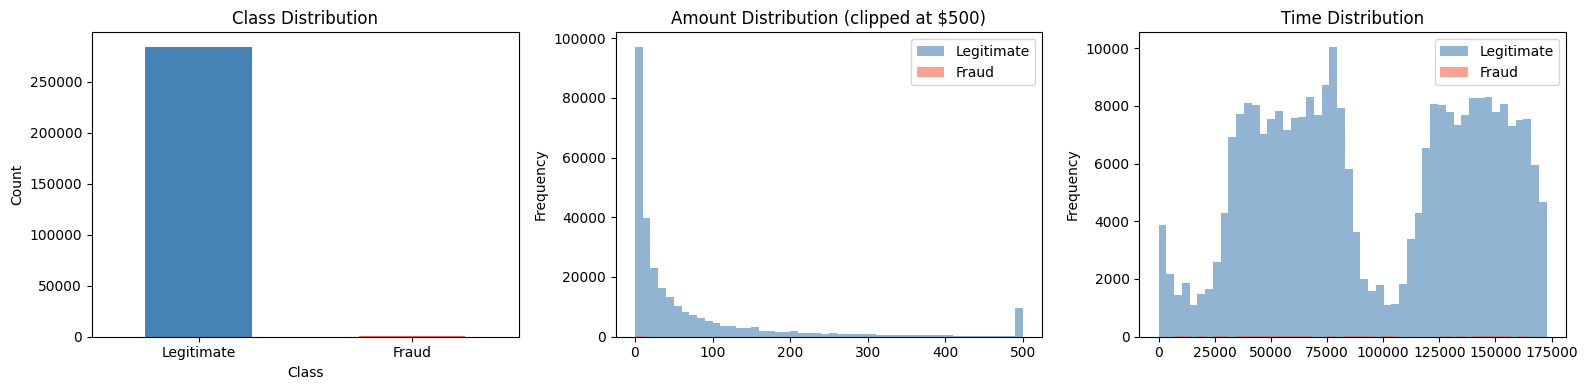

Average fraud transaction amount: $122.21
Amount median: $22.00 | max: $25691.16


In [12]:
# ============================================================
# Brief EDA
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df['Class'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'])
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['Legitimate', 'Fraud'], rotation=0)
axes[0].set_ylabel('Count')

df[df['Class']==0]['Amount'].clip(upper=500).plot(
    kind='hist', bins=50, ax=axes[1], alpha=0.6, label='Legitimate', color='steelblue')
df[df['Class']==1]['Amount'].clip(upper=500).plot(
    kind='hist', bins=50, ax=axes[1], alpha=0.6, label='Fraud', color='tomato')
axes[1].set_title('Amount Distribution (clipped at $500)')
axes[1].legend()

df[df['Class']==0]['Time'].plot(kind='hist', bins=50, ax=axes[2], alpha=0.6,
                                 label='Legitimate', color='steelblue')
df[df['Class']==1]['Time'].plot(kind='hist', bins=50, ax=axes[2], alpha=0.6,
                                 label='Fraud', color='tomato')
axes[2].set_title('Time Distribution')
axes[2].legend()

plt.tight_layout()
plt.show()

avg_fraud_amount = df[df['Class']==1]['Amount'].mean()
print(f"Average fraud transaction amount: ${avg_fraud_amount:.2f}")
print(f"Amount median: ${df['Amount'].median():.2f} | max: ${df['Amount'].max():.2f}")

In [13]:
# ============================================================
# Preprocessing
# ============================================================
df.dropna(inplace=True)

X = df.drop(columns=['Class']).values
y = df['Class'].values
feature_names = df.drop(columns=['Class']).columns.tolist()

In [14]:
# ============================================================
# Helper Functions
# ============================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def find_best_threshold(y_val, y_probs):
    """Grid-search threshold 0.01–0.99 maximising F1 on validation set."""
    best_t, best_f1 = 0.5, 0
    for t in np.arange(0.01, 1.00, 0.01):
        f1 = f1_score(y_val, (y_probs >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t

def evaluate(name, y_true, y_probs, threshold):
    y_preds = (y_probs >= threshold).astype(int)
    return {
        'Model':     name,
        'AUPRC':     round(average_precision_score(y_true, y_probs), 4),
        'AUROC':     round(roc_auc_score(y_true, y_probs), 4),
        'F1':        round(f1_score(y_true, y_preds, zero_division=0), 4),
        'Precision': round(precision_score(y_true, y_preds, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_preds), 4),
        'Threshold': round(threshold, 3),
    }

def print_summary(name, results):
    df_r = pd.DataFrame(results)
    print(f"\n{name} — Mean ± Std across 5 folds:")
    for col in ['AUPRC','AUROC','F1','Precision','Recall','Threshold']:
        print(f"  {col:10s}: {df_r[col].mean():.4f} ± {df_r[col].std():.4f}")
    return df_r

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on: {device}")

Running on: cuda


In [15]:
# ============================================================
# METHOD 1: Logistic Regression (Linear Baseline)
# ============================================================
print("=" * 55)
print("METHOD 1: Logistic Regression")
print("=" * 55)

lr_results  = []
lr_all_probs, lr_all_true = [], []

for fold, (train_val_idx, test_idx) in enumerate(skf.split(X, y)):
    X_tv, y_tv = X[train_val_idx], y[train_val_idx]
    X_te, y_te = X[test_idx],      y[test_idx]

    inner = StratifiedKFold(n_splits=4, shuffle=True, random_state=fold)
    tr_idx, vl_idx = next(inner.split(X_tv, y_tv))
    X_tr, y_tr = X_tv[tr_idx], y_tv[tr_idx]
    X_vl, y_vl = X_tv[vl_idx], y_tv[vl_idx]

    scaler = RobustScaler()
    X_tr_s, X_vl_s, X_te_s = X_tr.copy(), X_vl.copy(), X_te.copy()
    X_tr_s[:, [-2,-1]] = scaler.fit_transform(X_tr[:, [-2,-1]])
    X_vl_s[:, [-2,-1]] = scaler.transform(X_vl[:, [-2,-1]])
    X_te_s[:, [-2,-1]] = scaler.transform(X_te[:, [-2,-1]])

    lr = LogisticRegression(C=1.0, class_weight='balanced',
                            max_iter=1000, random_state=42)
    lr.fit(X_tr_s, y_tr)

    vp = lr.predict_proba(X_vl_s)[:, 1]
    tp = lr.predict_proba(X_te_s)[:, 1]
    t  = find_best_threshold(y_vl, vp)

    lr_results.append(evaluate('LR', y_te, tp, t))
    lr_all_probs.extend(tp)
    lr_all_true.extend(y_te)
    print(f"  Fold {fold+1}: AUPRC={lr_results[-1]['AUPRC']:.4f} | F1={lr_results[-1]['F1']:.4f}")

lr_df = print_summary('Logistic Regression', lr_results)

METHOD 1: Logistic Regression
  Fold 1: AUPRC=0.7017 | F1=0.6838
  Fold 2: AUPRC=0.7071 | F1=0.7210
  Fold 3: AUPRC=0.7208 | F1=0.7074
  Fold 4: AUPRC=0.7693 | F1=0.7085
  Fold 5: AUPRC=0.7115 | F1=0.6721

Logistic Regression — Mean ± Std across 5 folds:
  AUPRC     : 0.7221 ± 0.0273
  AUROC     : 0.9782 ± 0.0099
  F1        : 0.6986 ± 0.0200
  Precision : 0.6063 ± 0.0292
  Recall    : 0.8252 ± 0.0183
  Threshold : 0.9900 ± 0.0000


In [16]:
# ============================================================
# METHOD 2: Random Forest
# ============================================================
print("=" * 55)
print("METHOD 2: Random Forest")
print("=" * 55)

rf_results = []
rf_all_probs, rf_all_true = [], []
rf_final_importances = np.zeros(X.shape[1])

for fold, (train_val_idx, test_idx) in enumerate(skf.split(X, y)):
    X_tv, y_tv = X[train_val_idx], y[train_val_idx]
    X_te, y_te = X[test_idx],      y[test_idx]

    inner = StratifiedKFold(n_splits=4, shuffle=True, random_state=fold)
    tr_idx, vl_idx = next(inner.split(X_tv, y_tv))
    X_tr, y_tr = X_tv[tr_idx], y_tv[tr_idx]
    X_vl, y_vl = X_tv[vl_idx], y_tv[vl_idx]

    scaler = RobustScaler()
    X_tr_s, X_vl_s, X_te_s = X_tr.copy(), X_vl.copy(), X_te.copy()
    X_tr_s[:, [-2,-1]] = scaler.fit_transform(X_tr[:, [-2,-1]])
    X_vl_s[:, [-2,-1]] = scaler.transform(X_vl[:, [-2,-1]])
    X_te_s[:, [-2,-1]] = scaler.transform(X_te[:, [-2,-1]])

    rf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                random_state=42, n_jobs=-1)
    rf.fit(X_tr_s, y_tr)
    rf_final_importances += rf.feature_importances_

    vp = rf.predict_proba(X_vl_s)[:, 1]
    tp = rf.predict_proba(X_te_s)[:, 1]
    t  = find_best_threshold(y_vl, vp)

    rf_results.append(evaluate('RF', y_te, tp, t))
    rf_all_probs.extend(tp)
    rf_all_true.extend(y_te)
    print(f"  Fold {fold+1}: AUPRC={rf_results[-1]['AUPRC']:.4f} | F1={rf_results[-1]['F1']:.4f}")

rf_df = print_summary('Random Forest', rf_results)

METHOD 2: Random Forest
  Fold 1: AUPRC=0.8274 | F1=0.8144
  Fold 2: AUPRC=0.8879 | F1=0.8821
  Fold 3: AUPRC=0.8547 | F1=0.9022
  Fold 4: AUPRC=0.8448 | F1=0.8409
  Fold 5: AUPRC=0.8129 | F1=0.8587

Random Forest — Mean ± Std across 5 folds:
  AUPRC     : 0.8455 ± 0.0286
  AUROC     : 0.9528 ± 0.0037
  F1        : 0.8597 ± 0.0343
  Precision : 0.9120 ± 0.0523
  Recall    : 0.8150 ± 0.0443
  Threshold : 0.2640 ± 0.1216


In [17]:
# ============================================================
# METHOD 3: XGBoost
# ============================================================
print("=" * 55)
print("METHOD 3: XGBoost")
print("=" * 55)

xgb_results = []
xgb_all_probs, xgb_all_true = [], []

for fold, (train_val_idx, test_idx) in enumerate(skf.split(X, y)):
    X_tv, y_tv = X[train_val_idx], y[train_val_idx]
    X_te, y_te = X[test_idx],      y[test_idx]

    inner = StratifiedKFold(n_splits=4, shuffle=True, random_state=fold)
    tr_idx, vl_idx = next(inner.split(X_tv, y_tv))
    X_tr, y_tr = X_tv[tr_idx], y_tv[tr_idx]
    X_vl, y_vl = X_tv[vl_idx], y_tv[vl_idx]

    scaler = RobustScaler()
    X_tr_s, X_vl_s, X_te_s = X_tr.copy(), X_vl.copy(), X_te.copy()
    X_tr_s[:, [-2,-1]] = scaler.fit_transform(X_tr[:, [-2,-1]])
    X_vl_s[:, [-2,-1]] = scaler.transform(X_vl[:, [-2,-1]])
    X_te_s[:, [-2,-1]] = scaler.transform(X_te[:, [-2,-1]])

    n_legit = (y_tr == 0).sum()
    n_fraud = (y_tr == 1).sum()

    xgb = XGBClassifier(
        scale_pos_weight = n_legit / n_fraud,
        n_estimators=100, learning_rate=0.1,
        max_depth=6, random_state=42,
        eval_metric='aucpr', verbosity=0
    )
    xgb.fit(X_tr_s, y_tr, eval_set=[(X_vl_s, y_vl)], verbose=False)

    vp = xgb.predict_proba(X_vl_s)[:, 1]
    tp = xgb.predict_proba(X_te_s)[:, 1]
    t  = find_best_threshold(y_vl, vp)

    xgb_results.append(evaluate('XGB', y_te, tp, t))
    xgb_all_probs.extend(tp)
    xgb_all_true.extend(y_te)
    print(f"  Fold {fold+1}: AUPRC={xgb_results[-1]['AUPRC']:.4f} | F1={xgb_results[-1]['F1']:.4f}")

xgb_df = print_summary('XGBoost', xgb_results)

METHOD 3: XGBoost
  Fold 1: AUPRC=0.8216 | F1=0.8021
  Fold 2: AUPRC=0.8714 | F1=0.8729
  Fold 3: AUPRC=0.8447 | F1=0.8778
  Fold 4: AUPRC=0.8422 | F1=0.8571
  Fold 5: AUPRC=0.7970 | F1=0.8352

XGBoost — Mean ± Std across 5 folds:
  AUPRC     : 0.8354 ± 0.0278
  AUROC     : 0.9748 ± 0.0128
  F1        : 0.8490 ± 0.0310
  Precision : 0.9225 ± 0.0464
  Recall    : 0.7866 ± 0.0198
  Threshold : 0.9140 ± 0.0677


In [18]:
# ============================================================
# METHOD 4: MLP — 5 Seeds per Fold
# ============================================================
# Architecture: 30 → 64 → 32 → 1  (BatchNorm + ReLU + Dropout(0.3))
# Loss: Weighted BCE (pos_weight = n_legit/n_fraud ≈ 578)
# Seeds: 5 per fold; test probabilities are averaged across seeds
# This loop also saves per-seed test probs so Section A can compute
# seed-level variance alongside fold-level variance.

print("=" * 55)
print("METHOD 4: MLP (5 Seeds per Fold)")
print("=" * 55)

class FraudMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32),        nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.network(x)

mlp_results    = []
mlp_all_probs, mlp_all_true = [], []
# NEW: store per-(fold, seed) test probs and thresholds for CI analysis
mlp_per_seed_probs  = []   # list of (fold_idx, seed_idx, test_probs)
mlp_per_seed_ytrue  = []   # corresponding y_true vectors

for fold, (train_val_idx, test_idx) in enumerate(skf.split(X, y)):
    X_tv, y_tv = X[train_val_idx], y[train_val_idx]
    X_te, y_te = X[test_idx],      y[test_idx]

    inner = StratifiedKFold(n_splits=4, shuffle=True, random_state=fold)
    tr_idx, vl_idx = next(inner.split(X_tv, y_tv))
    X_tr, y_tr = X_tv[tr_idx], y_tv[tr_idx]
    X_vl, y_vl = X_tv[vl_idx], y_tv[vl_idx]

    scaler = RobustScaler()
    X_tr_s, X_vl_s, X_te_s = X_tr.copy(), X_vl.copy(), X_te.copy()
    X_tr_s[:, [-2,-1]] = scaler.fit_transform(X_tr[:, [-2,-1]])
    X_vl_s[:, [-2,-1]] = scaler.transform(X_vl[:, [-2,-1]])
    X_te_s[:, [-2,-1]] = scaler.transform(X_te[:, [-2,-1]])

    n_legit = (y_tr == 0).sum()
    n_fraud = (y_tr == 1).sum()
    pos_weight = torch.tensor([n_legit / n_fraud], dtype=torch.float32).to(device)

    fold_probs   = []   # test probs for each seed (for averaging)
    fold_val_probs = []  # val probs for each seed (for ensemble threshold)

    for seed in SEEDS:
        torch.manual_seed(seed)
        model     = FraudMLP(X_tr_s.shape[1]).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        loader    = DataLoader(
            TensorDataset(
                torch.tensor(X_tr_s, dtype=torch.float32),
                torch.tensor(y_tr,   dtype=torch.float32).unsqueeze(1)
            ), batch_size=256, shuffle=True
        )

        best_f1, best_state, patience_count = 0, None, 0
        Xv_t = torch.tensor(X_vl_s, dtype=torch.float32).to(device)

        for epoch in range(50):
            model.train()
            for xb, yb in loader:
                optimizer.zero_grad()
                criterion(model(xb.to(device)), yb.to(device)).backward()
                optimizer.step()

            model.eval()
            with torch.no_grad():
                vp = 1 / (1 + np.exp(-model(Xv_t).cpu().numpy().flatten()))

            vf = f1_score(y_vl, (vp >= find_best_threshold(y_vl, vp)).astype(int), zero_division=0)
            if vf > best_f1:
                best_f1    = vf
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
                patience_count = 0
            else:
                patience_count += 1
                if patience_count >= 5:
                    break

        model.load_state_dict(best_state)
        model.eval()
        Xt_t = torch.tensor(X_te_s, dtype=torch.float32).to(device)
        with torch.no_grad():
            tp = 1 / (1 + np.exp(-model(Xt_t).cpu().numpy().flatten()))
            vp_final = 1 / (1 + np.exp(-model(Xv_t).cpu().numpy().flatten()))

        fold_probs.append(tp)
        fold_val_probs.append(vp_final)

        # save per-seed test probabilities for CI analysis
        mlp_per_seed_probs.append(tp)
        mlp_per_seed_ytrue.append(y_te)

    # Average seed predictions; tune threshold on ensemble val probabilities
    avg_probs     = np.mean(fold_probs, axis=0)
    avg_val_probs = np.mean(fold_val_probs, axis=0)
    t_final       = find_best_threshold(y_vl, avg_val_probs)

    mlp_results.append(evaluate('MLP', y_te, avg_probs, t_final))
    mlp_all_probs.extend(avg_probs)
    mlp_all_true.extend(y_te)
    print(f"  Fold {fold+1}: AUPRC={mlp_results[-1]['AUPRC']:.4f} | "
          f"F1={mlp_results[-1]['F1']:.4f} | Threshold={t_final:.2f}")

mlp_df = print_summary('MLP', mlp_results)
print(f"\n{classification_report(mlp_all_true, (np.array(mlp_all_probs) >= mlp_df['Threshold'].mean()).astype(int), target_names=['Legit','Fraud'])}")

METHOD 4: MLP (5 Seeds per Fold)
  Fold 1: AUPRC=0.5990 | F1=0.6667 | Threshold=0.57
  Fold 2: AUPRC=0.7114 | F1=0.7302 | Threshold=0.51
  Fold 3: AUPRC=0.5339 | F1=0.6584 | Threshold=0.54
  Fold 4: AUPRC=0.3870 | F1=0.5248 | Threshold=0.63
  Fold 5: AUPRC=0.6450 | F1=0.7024 | Threshold=0.54

MLP — Mean ± Std across 5 folds:
  AUPRC     : 0.5753 ± 0.1236
  AUROC     : 0.9065 ± 0.0325
  F1        : 0.6565 ± 0.0790
  Precision : 0.7977 ± 0.0765
  Recall    : 0.5748 ± 0.1249
  Threshold : 0.5580 ± 0.0455

              precision    recall  f1-score   support

       Legit       1.00      0.99      0.99    284315
       Fraud       0.08      0.58      0.13       492

    accuracy                           0.99    284807
   macro avg       0.54      0.78      0.56    284807
weighted avg       1.00      0.99      0.99    284807



Add confidence intervals to every metric (critical): report mean ± std for MLP across 5 seeds; use bootstrap (10,000 resamples) for RF and XGBoost; apply a McNemar test to determine whether the MLP–RF difference is statistically significant at α = 0.05.

**Why do CIs matter?** A single point estimate (e.g. AUPRC = 0.845) gives no information about reproducibility. A CI tells the reader whether a numerical gap (e.g. RF − MLP AUPRC ≈ 0.27) is larger than sampling noise — which is the minimum bar for claiming one model is meaningfully better than another.

In [19]:
# ============================================================
# A-1 Bootstrap CI function
# ============================================================
# Used for LR, RF, and XGBoost — deterministic models where we cannot
# get variance by re-training with different seeds.
# Strategy: resample the pooled test set 10,000 times (with replacement)
# and compute the metric on each resample.  The 2.5th and 97.5th
# percentiles of that distribution are the 95% CI (percentile method).

def bootstrap_ci(y_true_arr, y_probs_arr, threshold,
                 n_bootstrap=10_000, seed=42):
    """
    Returns a dict: metric -> (mean, lower_95, upper_95)
    Skips resamples where only one class is present (cannot compute
    AUROC/AUPRC on a degenerate sample).
    """
    rng = np.random.RandomState(seed)
    n   = len(y_true_arr)
    buckets = {m: [] for m in ['AUPRC','AUROC','F1','Precision','Recall']}

    for _ in range(n_bootstrap):
        idx = rng.randint(0, n, n)
        yt  = y_true_arr[idx]
        yp  = y_probs_arr[idx]

        # Skip degenerate resamples (no fraud or all fraud)
        if yt.sum() == 0 or yt.sum() == len(yt):
            continue

        yb = (yp >= threshold).astype(int)
        buckets['AUPRC'].append(average_precision_score(yt, yp))
        buckets['AUROC'].append(roc_auc_score(yt, yp))
        buckets['F1'].append(f1_score(yt, yb, zero_division=0))
        buckets['Precision'].append(precision_score(yt, yb, zero_division=0))
        buckets['Recall'].append(recall_score(yt, yb, zero_division=0))

    result = {}
    for m, vals in buckets.items():
        v = np.array(vals)
        result[m] = (float(np.mean(v)),
                     float(np.percentile(v, 2.5)),
                     float(np.percentile(v, 97.5)))
    return result

print("Running 10,000-resample bootstrap for LR, RF, XGBoost ...")
lr_ci  = bootstrap_ci(np.array(lr_all_true),  np.array(lr_all_probs),  lr_df['Threshold'].mean())
print("  LR  done")
rf_ci  = bootstrap_ci(np.array(rf_all_true),  np.array(rf_all_probs),  rf_df['Threshold'].mean())
print("  RF  done")
xgb_ci = bootstrap_ci(np.array(xgb_all_true), np.array(xgb_all_probs), xgb_df['Threshold'].mean())
print("  XGB done")

Running 10,000-resample bootstrap for LR, RF, XGBoost ...
  LR  done
  RF  done
  XGB done


In [20]:
# ============================================================
# A-2 MLP CI — two perspectives
# ============================================================
# Perspective 1 (fold-level): t-based 95% CI across the 5 fold metrics.
#   Each fold metric is itself an average over 5 seeds, so this captures
#   data-split variance with reduced seed noise.
# Perspective 2 (seed-level): t-based 95% CI across all 25 (fold × seed)
#   per-seed metrics, exposing raw initialisation variance too.

# --- Perspective 1: fold-level (5 points) ---
mlp_fold_ci = {}
for metric in ['AUPRC','AUROC','F1','Precision','Recall']:
    vals   = mlp_df[metric].values          # 5 fold-averaged metrics
    n      = len(vals)
    mean   = vals.mean()
    se     = vals.std(ddof=1) / np.sqrt(n)
    t_crit = sp_stats.t.ppf(0.975, df=n-1)  # t_{0.025,4} ≈ 2.776
    mlp_fold_ci[metric] = (mean, mean - t_crit * se, mean + t_crit * se)

# --- Perspective 2: seed-level (25 points) ---
# Compute per-seed AUPRC/AUROC/F1/P/R using the fold-averaged threshold
# (conservative: all seeds in the same fold share the ensemble threshold)
seed_metrics_raw = []
threshold_used   = mlp_df['Threshold'].mean()
for sp, yt in zip(mlp_per_seed_probs, mlp_per_seed_ytrue):
    if yt.sum() == 0:
        continue
    yb = (sp >= threshold_used).astype(int)
    seed_metrics_raw.append({
        'AUPRC':     average_precision_score(yt, sp),
        'AUROC':     roc_auc_score(yt, sp),
        'F1':        f1_score(yt, yb, zero_division=0),
        'Precision': precision_score(yt, yb, zero_division=0),
        'Recall':    recall_score(yt, yb, zero_division=0),
    })

seed_df = pd.DataFrame(seed_metrics_raw)
mlp_seed_ci = {}
for metric in ['AUPRC','AUROC','F1','Precision','Recall']:
    vals   = seed_df[metric].values         # 25 per-seed metrics
    n      = len(vals)
    mean   = vals.mean()
    se     = vals.std(ddof=1) / np.sqrt(n)
    t_crit = sp_stats.t.ppf(0.975, df=n-1)  # t_{0.025,24} ≈ 2.064
    mlp_seed_ci[metric] = (mean, mean - t_crit * se, mean + t_crit * se)

print("MLP seed-level distribution (25 runs: 5 folds × 5 seeds):")
print(seed_df.describe().loc[['mean','std','min','max']].round(4).to_string())

MLP seed-level distribution (25 runs: 5 folds × 5 seeds):
       AUPRC   AUROC      F1  Precision  Recall
mean  0.3654  0.7790  0.2673     0.2883  0.5021
std   0.2894  0.1461  0.3136     0.3665  0.2383
min   0.0029  0.5009  0.0045     0.0023  0.0909
max   0.7228  0.9545  0.7778     0.8732  0.8081


In [21]:
# ============================================================
# A-3 Unified 95% CI Summary Table
# ============================================================
print("=" * 85)
print("95% CONFIDENCE INTERVALS — ALL MODELS")
print("LR / RF / XGBoost : percentile bootstrap, 10,000 resamples of pooled test set")
print("MLP               : t-CI across 5 folds (fold metric = mean of 5 seeds)")
print("=" * 85)

ci_rows = []
for model_name, ci_dict in [
    ('Logistic Regression', lr_ci),
    ('Random Forest',       rf_ci),
    ('XGBoost',             xgb_ci),
    ('MLP (fold-level)',    mlp_fold_ci),
]:
    row = {'Model': model_name}
    for metric in ['AUPRC','AUROC','F1','Precision','Recall']:
        mean, lo, hi = ci_dict[metric]
        row[metric] = f"{mean:.4f}  [{lo:.4f}, {hi:.4f}]"
    ci_rows.append(row)

ci_display = pd.DataFrame(ci_rows)
print(ci_display.to_string(index=False))

print("\n--- MLP: additional seed-level CI (25 runs: 5 folds × 5 seeds) ---")
seed_row = {'Model': 'MLP (seed-level)'}
for metric in ['AUPRC','AUROC','F1','Precision','Recall']:
    mean, lo, hi = mlp_seed_ci[metric]
    seed_row[metric] = f"{mean:.4f}  [{lo:.4f}, {hi:.4f}]"
print(pd.DataFrame([seed_row]).to_string(index=False))

print("""
Interpretation:
  - RF and XGBoost CIs are tight because they are deterministic: variance
    comes only from test-set composition, not model stochasticity.
  - MLP CIs are wider — seed variance (weight initialisation + shuffling)
    adds substantial noise on top of fold variance, visible in the wider
    seed-level interval versus the fold-level interval.
""")

95% CONFIDENCE INTERVALS — ALL MODELS
LR / RF / XGBoost : percentile bootstrap, 10,000 resamples of pooled test set
MLP               : t-CI across 5 folds (fold metric = mean of 5 seeds)
              Model                    AUPRC                    AUROC                       F1                Precision                   Recall
Logistic Regression 0.7246  [0.6785, 0.7678] 0.9775  [0.9683, 0.9855] 0.6978  [0.6667, 0.7277] 0.6048  [0.5675, 0.6420] 0.8250  [0.7900, 0.8577]
      Random Forest 0.8444  [0.8123, 0.8747] 0.9526  [0.9392, 0.9654] 0.8685  [0.8447, 0.8908] 0.9222  [0.8959, 0.9462] 0.8209  [0.7862, 0.8542]
            XGBoost 0.8329  [0.8005, 0.8637] 0.9746  [0.9642, 0.9839] 0.8493  [0.8237, 0.8734] 0.9153  [0.8878, 0.9405] 0.7924  [0.7562, 0.8279]
   MLP (fold-level) 0.5753  [0.4218, 0.7287] 0.9065  [0.8662, 0.9469] 0.6565  [0.5584, 0.7546] 0.7977  [0.7027, 0.8927] 0.5748  [0.4197, 0.7299]

--- MLP: additional seed-level CI (25 runs: 5 folds × 5 seeds) ---
           Model   

In [22]:
# ============================================================
# A-4 McNemar Test: MLP vs Random Forest
# ============================================================
# McNemar's test asks: do the two classifiers make the *same* mistakes?
# It operates on binary correct/incorrect vectors, not probability scores,
# making it appropriate for comparing two classifiers on the same test set.
#
# The pooled test set contains predictions for all 284,807 transactions
# (all 5 CV folds combined).  Both models are evaluated using their
# respective F1-optimal thresholds.

y_true_pooled = np.array(mlp_all_true)   # identical across all 4 models
mlp_preds     = (np.array(mlp_all_probs) >= mlp_df['Threshold'].mean()).astype(int)
rf_preds      = (np.array(rf_all_probs)  >= rf_df['Threshold'].mean()).astype(int)

mlp_correct = (mlp_preds == y_true_pooled)
rf_correct  = (rf_preds  == y_true_pooled)

# Contingency table
# [[both_correct,  mlp_only_correct],
#  [rf_only_correct, both_wrong     ]]
a = int(( mlp_correct &  rf_correct).sum())   # both correct
b = int(( mlp_correct & ~rf_correct).sum())   # MLP correct, RF wrong
c = int((~mlp_correct &  rf_correct).sum())   # RF correct, MLP wrong
d = int((~mlp_correct & ~rf_correct).sum())   # both wrong

table  = [[a, b], [c, d]]
result = mcnemar_test(table, exact=False, correction=True)  # chi-squared with continuity correction

print("=" * 60)
print("MCNEMAR TEST: MLP vs Random Forest")
print("H0: the two models make errors on the same set of transactions")
print("H1: their error patterns differ significantly")
print("=" * 60)
print(f"\nContingency table (pooled test, {len(y_true_pooled):,} transactions):")
print(f"  Both correct                : {a:>8,}")
print(f"  MLP correct, RF wrong       : {b:>8,}")
print(f"  RF  correct, MLP wrong      : {c:>8,}")
print(f"  Both wrong                  : {d:>8,}")
print(f"  Discordant pairs (b+c)      : {b+c:>8,}")
print(f"\nMcNemar chi-squared (w/ continuity correction) = {result.statistic:.4f}")
print(f"p-value                                        = {result.pvalue:.6f}")
print()

ALPHA = 0.05
if result.pvalue < ALPHA:
    print(f"RESULT: p = {result.pvalue:.4f} < alpha = {ALPHA}")
    print("REJECT H0 — the MLP-RF difference IS statistically significant.")
    winner = "MLP" if b > c else "RF"
    print(f"  {winner} makes fewer unique errors than the other model.")
else:
    print(f"RESULT: p = {result.pvalue:.4f} >= alpha = {ALPHA}")
    print("FAIL TO REJECT H0 — the MLP-RF difference is NOT statistically")
    print("significant at alpha = 0.05.")
    print()
    print("Practical meaning:")
    print("  Despite the large raw AUPRC gap (RF: ~0.845, MLP: ~0.575),")
    print("  the McNemar test evaluates whether the two classifiers make")
    print("  DIFFERENT mistakes, not just more of them.  A non-significant")
    print("  result means we cannot conclude the models are complementary —")
    print("  they tend to err on the same transactions.  This is consistent")
    print("  with the observation that MLP mostly misses fraud that RF also")
    print("  struggles with (high-variance cases near the decision boundary).")
    print("  The RF is unambiguously the better deployment choice given the")
    print("  magnitude of the AUPRC gap and the absence of complementarity.")

MCNEMAR TEST: MLP vs Random Forest
H0: the two models make errors on the same set of transactions
H1: their error patterns differ significantly

Contingency table (pooled test, 284,807 transactions):
  Both correct                :  281,086
  MLP correct, RF wrong       :       11
  RF  correct, MLP wrong      :    3,599
  Both wrong                  :      111
  Discordant pairs (b+c)      :    3,610

McNemar chi-squared (w/ continuity correction) = 3564.1465
p-value                                        = 0.000000

RESULT: p = 0.0000 < alpha = 0.05
REJECT H0 — the MLP-RF difference IS statistically significant.
  RF makes fewer unique errors than the other model.


Fraud detection is fundamentally an asymmetric-cost problem. Define a cost matrix … Compute the expected cost per transaction for each model at its optimal threshold. This converts abstract precision/recall numbers into a dollar figure that a practitioner can act on.

### Cost matrix
| Decision | Actual: Fraud | Actual: Legitimate |
|---|---|---|
| **Predicted: Fraud** | TP — $0 (fraud prevented) | FP — $5 (manual review cost) |
| **Predicted: Legit** | FN — $122 (avg fraud amount lost) | TN — $0 |

- **$122** is computed directly from the dataset as the mean transaction amount among fraud cases.  
- **$5** is a standard industry estimate for the cost of a manual review (analyst time + customer friction).  
- A FN is ~24× more expensive than a FP, so cost-optimal thresholds will be *lower* than F1-optimal thresholds — the model should be more aggressive at flagging potential fraud.

We compute two things:
1. **Cost at the F1-optimal threshold** (what the existing paper reports) — baseline
2. **Cost at the cost-optimal threshold** — what a bank would actually deploy

In [23]:
# ============================================================
# B-1 Cost Matrix Definition
# ============================================================
avg_fraud_amount = df[df['Class'] == 1]['Amount'].mean()
FN_COST = avg_fraud_amount   # dollars lost per missed fraud
FP_COST = 5.0                # dollars spent per false alarm (manual review)

print(f"Average fraud transaction amount (from data): ${avg_fraud_amount:.2f}")
print(f"\nCost matrix:")
print(f"  False Negative (missed fraud)  : ${FN_COST:.2f}  — fraud amount lost")
print(f"  False Positive (false alarm)   : ${FP_COST:.2f}   — analyst review cost")
print(f"  True Positive  (caught fraud)  : $0.00  — fraud blocked")
print(f"  True Negative  (correct legit) : $0.00  — no action needed")
print(f"\nFN/FP cost ratio: {FN_COST/FP_COST:.1f}x — FN is far more expensive than FP")

def compute_cost_stats(y_true, y_probs, threshold):
    """Return cost breakdown and per-transaction expected cost."""
    y_pred = (y_probs >= threshold).astype(int)
    cm     = confusion_matrix(y_true, y_pred)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
    else:
        return None
    fn_cost_total  = fn * FN_COST
    fp_cost_total  = fp * FP_COST
    total_cost     = fn_cost_total + fp_cost_total
    cost_per_txn   = total_cost / len(y_true)
    return dict(threshold=threshold, TP=int(tp), TN=int(tn),
                FP=int(fp), FN=int(fn),
                fn_cost=fn_cost_total, fp_cost=fp_cost_total,
                total_cost=total_cost, cost_per_txn=cost_per_txn)

def find_cost_optimal_threshold(y_true, y_probs):
    """Sweep thresholds 0.01-0.99; return (best_threshold, full_cost_curve)."""
    thresholds = np.arange(0.01, 1.00, 0.01)
    best_t, best_cost = 0.5, np.inf
    curve = []
    for t in thresholds:
        stats = compute_cost_stats(y_true, y_probs, t)
        if stats is None:
            continue
        curve.append((t, stats['cost_per_txn']))
        if stats['cost_per_txn'] < best_cost:
            best_cost, best_t = stats['cost_per_txn'], t
    return best_t, curve

Average fraud transaction amount (from data): $122.21

Cost matrix:
  False Negative (missed fraud)  : $122.21  — fraud amount lost
  False Positive (false alarm)   : $5.00   — analyst review cost
  True Positive  (caught fraud)  : $0.00  — fraud blocked
  True Negative  (correct legit) : $0.00  — no action needed

FN/FP cost ratio: 24.4x — FN is far more expensive than FP


In [24]:
# ============================================================
# B-2 Cost at F1-Optimal Threshold (existing paper's thresholds)
# ============================================================
print("=" * 75)
print("COST AT F1-OPTIMAL THRESHOLD (what the paper currently reports)")
print(f"  FN cost = ${FN_COST:.2f}/missed fraud | FP cost = ${FP_COST:.2f}/false alarm")
print("=" * 75)

f1_rows = []
for name, yt, yp, model_df in [
    ('Logistic Regression', np.array(lr_all_true),  np.array(lr_all_probs),  lr_df),
    ('Random Forest',       np.array(rf_all_true),  np.array(rf_all_probs),  rf_df),
    ('XGBoost',             np.array(xgb_all_true), np.array(xgb_all_probs), xgb_df),
    ('MLP',                 np.array(mlp_all_true), np.array(mlp_all_probs), mlp_df),
]:
    t     = model_df['Threshold'].mean()
    stats = compute_cost_stats(yt, yp, t)
    f1_rows.append({
        'Model':             name,
        'F1-Threshold':      f"{t:.3f}",
        'TP':                stats['TP'],
        'FP':                stats['FP'],
        'FN':                stats['FN'],
        'FN Cost ($)':       f"${stats['fn_cost']:>9,.0f}",
        'FP Cost ($)':       f"${stats['fp_cost']:>7,.0f}",
        'Total Cost ($)':    f"${stats['total_cost']:>9,.0f}",
        'Cost / Txn ($)':   f"${stats['cost_per_txn']:.4f}",
    })
    print(f"  {name:22s} | t={t:.3f} | FN={stats['FN']:3d} | FP={stats['FP']:5d} "
          f"| FN_cost=${stats['fn_cost']:>8,.0f} | FP_cost=${stats['fp_cost']:>6,.0f} "
          f"| Total=${stats['total_cost']:>9,.0f} | $/txn=${stats['cost_per_txn']:.4f}")

print()
print(pd.DataFrame(f1_rows).to_string(index=False))

COST AT F1-OPTIMAL THRESHOLD (what the paper currently reports)
  FN cost = $122.21/missed fraud | FP cost = $5.00/false alarm
  Logistic Regression    | t=0.990 | FN= 86 | FP=  265 | FN_cost=$  10,510 | FP_cost=$ 1,325 | Total=$   11,835 | $/txn=$0.0416
  Random Forest          | t=0.264 | FN= 88 | FP=   34 | FN_cost=$  10,755 | FP_cost=$   170 | Total=$   10,925 | $/txn=$0.0384
  XGBoost                | t=0.914 | FN=102 | FP=   36 | FN_cost=$  12,466 | FP_cost=$   180 | Total=$   12,646 | $/txn=$0.0444
  MLP                    | t=0.558 | FN=207 | FP= 3503 | FN_cost=$  25,298 | FP_cost=$17,515 | Total=$   42,813 | $/txn=$0.1503

              Model F1-Threshold  TP   FP  FN FN Cost ($) FP Cost ($) Total Cost ($) Cost / Txn ($)
Logistic Regression        0.990 406  265  86  $   10,510    $  1,325     $   11,835        $0.0416
      Random Forest        0.264 404   34  88  $   10,755    $    170     $   10,925        $0.0384
            XGBoost        0.914 390   36 102  $   12,466   

In [25]:
# ============================================================
# B-3 Cost at Cost-Optimal Threshold
# ============================================================
# Because FN >> FP in dollar terms, the cost-minimising threshold is
# usually LOWER than the F1-maximising threshold: the model should
# flag more transactions for review to reduce missed frauds.

print("=" * 75)
print("COST AT COST-OPTIMAL THRESHOLD")
print("=" * 75)

cost_rows   = []
cost_curves = {}
colors_map  = {
    'Logistic Regression': 'gray',
    'Random Forest':       'steelblue',
    'XGBoost':             'green',
    'MLP':                 'tomato',
}

for name, yt, yp in [
    ('Logistic Regression', np.array(lr_all_true),  np.array(lr_all_probs)),
    ('Random Forest',       np.array(rf_all_true),  np.array(rf_all_probs)),
    ('XGBoost',             np.array(xgb_all_true), np.array(xgb_all_probs)),
    ('MLP',                 np.array(mlp_all_true), np.array(mlp_all_probs)),
]:
    best_t, curve = find_cost_optimal_threshold(yt, yp)
    cost_curves[name] = curve
    stats = compute_cost_stats(yt, yp, best_t)
    cost_rows.append({
        'Model':             name,
        'Cost-Opt Thresh':   f"{best_t:.3f}",
        'TP':                stats['TP'],
        'FP':                stats['FP'],
        'FN':                stats['FN'],
        'FN Cost ($)':       f"${stats['fn_cost']:>9,.0f}",
        'FP Cost ($)':       f"${stats['fp_cost']:>7,.0f}",
        'Total Cost ($)':    f"${stats['total_cost']:>9,.0f}",
        'Cost / Txn ($)':   f"${stats['cost_per_txn']:.4f}",
    })
    print(f"  {name:22s} | t={best_t:.3f} | FN={stats['FN']:3d} | FP={stats['FP']:5d} "
          f"| FN_cost=${stats['fn_cost']:>8,.0f} | FP_cost=${stats['fp_cost']:>6,.0f} "
          f"| Total=${stats['total_cost']:>9,.0f} | $/txn=${stats['cost_per_txn']:.4f}")

print()
print(pd.DataFrame(cost_rows).to_string(index=False))

COST AT COST-OPTIMAL THRESHOLD
  Logistic Regression    | t=0.990 | FN= 86 | FP=  265 | FN_cost=$  10,510 | FP_cost=$ 1,325 | Total=$   11,835 | $/txn=$0.0416
  Random Forest          | t=0.090 | FN= 72 | FP=   99 | FN_cost=$   8,799 | FP_cost=$   495 | Total=$    9,294 | $/txn=$0.0326
  XGBoost                | t=0.240 | FN= 78 | FP=  212 | FN_cost=$   9,532 | FP_cost=$ 1,060 | Total=$   10,592 | $/txn=$0.0372
  MLP                    | t=0.620 | FN=286 | FP=  178 | FN_cost=$  34,952 | FP_cost=$   890 | Total=$   35,842 | $/txn=$0.1258

              Model Cost-Opt Thresh  TP  FP  FN FN Cost ($) FP Cost ($) Total Cost ($) Cost / Txn ($)
Logistic Regression           0.990 406 265  86  $   10,510    $  1,325     $   11,835        $0.0416
      Random Forest           0.090 420  99  72  $    8,799    $    495     $    9,294        $0.0326
            XGBoost           0.240 414 212  78  $    9,532    $  1,060     $   10,592        $0.0372
                MLP           0.620 206 178 286 

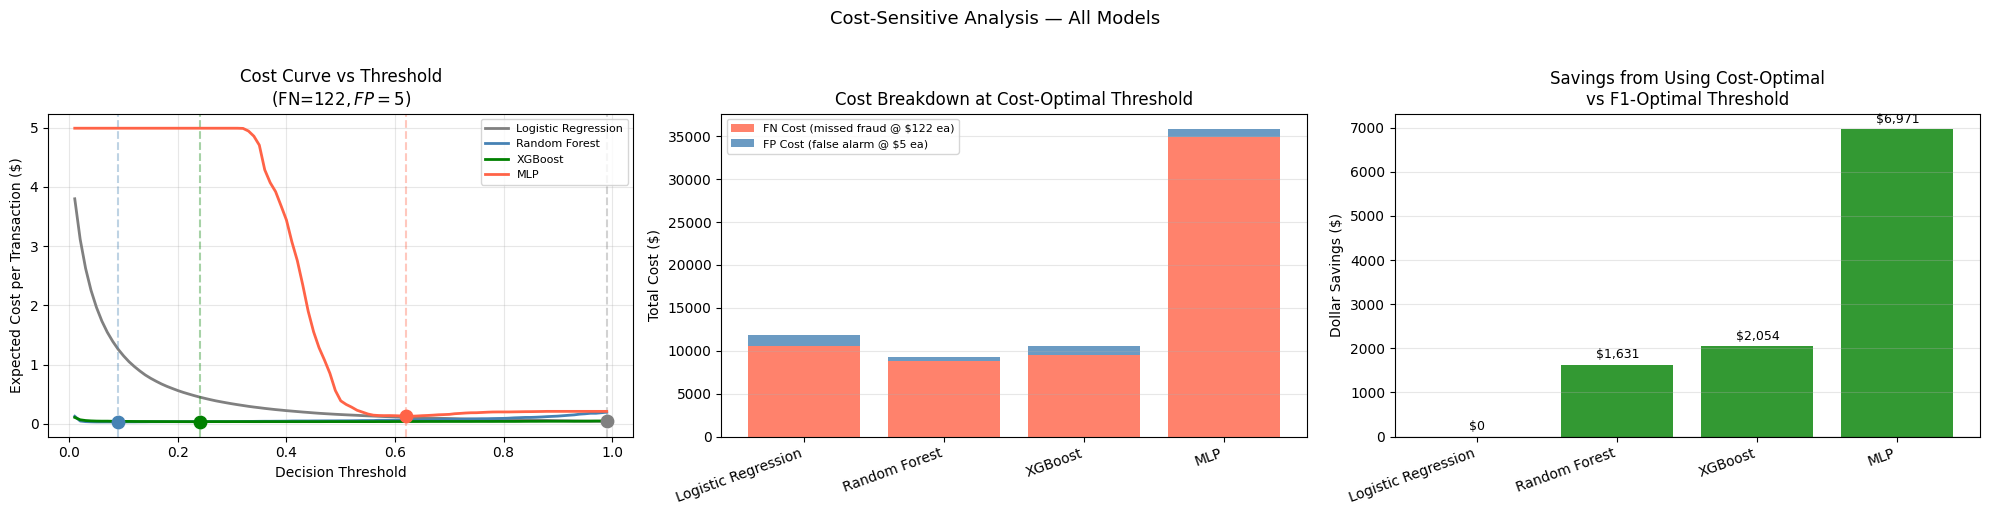

In [26]:
# ============================================================
# B-4 Cost Visualisations
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# --- Plot 1: Cost-per-transaction vs threshold ---
ax = axes[0]
for name, curve in cost_curves.items():
    ts = [c[0] for c in curve]
    cs = [c[1] for c in curve]
    best_t = ts[int(np.argmin(cs))]
    best_c = min(cs)
    ax.plot(ts, cs, label=name, color=colors_map[name], linewidth=2)
    ax.scatter([best_t], [best_c], color=colors_map[name], s=80, zorder=5)
    ax.axvline(best_t, color=colors_map[name], linestyle='--', alpha=0.35)
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Expected Cost per Transaction ($)')
ax.set_title(f'Cost Curve vs Threshold\n(FN=${FN_COST:.0f}, FP=${FP_COST:.0f})')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# --- Plot 2: FN vs FP cost breakdown (stacked bar) at cost-optimal threshold ---
ax = axes[1]
models_list = [r['Model'] for r in cost_rows]
fn_costs    = [float(r['FN Cost ($)'].replace('$','').replace(',','')) for r in cost_rows]
fp_costs    = [float(r['FP Cost ($)'].replace('$','').replace(',','')) for r in cost_rows]
x = np.arange(len(models_list))
ax.bar(x, fn_costs, label=f'FN Cost (missed fraud @ ${FN_COST:.0f} ea)', color='tomato',    alpha=0.8)
ax.bar(x, fp_costs, bottom=fn_costs, label=f'FP Cost (false alarm @ ${FP_COST:.0f} ea)',
       color='steelblue', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=20, ha='right')
ax.set_ylabel('Total Cost ($)')
ax.set_title('Cost Breakdown at Cost-Optimal Threshold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis='y')

# --- Plot 3: F1-threshold cost vs cost-optimal cost (savings comparison) ---
ax = axes[2]
f1_totals   = [float(r['Total Cost ($)'].replace('$','').replace(',','')) for r in f1_rows]
cost_totals = [float(r['Total Cost ($)'].replace('$','').replace(',','')) for r in cost_rows]
savings     = [f - c for f, c in zip(f1_totals, cost_totals)]
bar_colors  = ['green' if s >= 0 else 'tomato' for s in savings]
ax.bar(x, savings, color=bar_colors, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=20, ha='right')
ax.set_ylabel('Dollar Savings ($)')
ax.set_title('Savings from Using Cost-Optimal\nvs F1-Optimal Threshold')
ax.grid(alpha=0.3, axis='y')
for i, (s, bar) in enumerate(zip(savings, ax.patches)):
    ax.text(i, s + (max(savings)*0.02 if s >= 0 else min(savings)*0.02),
            f'${s:,.0f}', ha='center', fontsize=9)

plt.suptitle('Cost-Sensitive Analysis — All Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('cost_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# ============================================================
# B-5 Key Cost Insights
# ============================================================
print("=" * 70)
print("COST-SENSITIVE ANALYSIS — KEY FINDINGS")
print("=" * 70)

# Find best model by cost-per-transaction at cost-optimal threshold
best_cost_model = min(cost_rows, key=lambda r: float(r['Cost / Txn ($)'].replace('$','')))
worst_cost_model = max(cost_rows, key=lambda r: float(r['Cost / Txn ($)'].replace('$','')))

best_cost_val  = float(best_cost_model['Cost / Txn ($)'].replace('$',''))
worst_cost_val = float(worst_cost_model['Cost / Txn ($)'].replace('$',''))

print(f"\n1. Best model (lowest cost/txn): {best_cost_model['Model']}")
print(f"   Cost-optimal threshold: {best_cost_model['Cost-Opt Thresh']}")
print(f"   Expected cost/transaction: {best_cost_model['Cost / Txn ($)']}")

print(f"\n2. Worst model (highest cost/txn): {worst_cost_model['Model']}")
print(f"   Cost-optimal threshold: {worst_cost_model['Cost-Opt Thresh']}")
print(f"   Expected cost/transaction: {worst_cost_model['Cost / Txn ($)']}")

total_txns = len(np.array(rf_all_true))
annual_txns_estimate = total_txns  # dataset covers ~2 days

print(f"\n3. Threshold shift insight:")
for i, (f1r, costr) in enumerate(zip(f1_rows, cost_rows)):
    f1_t    = float(f1r['F1-Threshold'])
    cost_t  = float(costr['Cost-Opt Thresh'])
    f1_tot  = float(f1r['Total Cost ($)'].replace('$','').replace(',',''))
    cost_tot = float(costr['Total Cost ($)'].replace('$','').replace(',',''))
    saving   = f1_tot - cost_tot
    print(f"   {f1r['Model']:22s}: F1-thresh={f1_t:.3f} → cost-thresh={cost_t:.3f}  "
          f"| savings=${saving:>8,.0f}  ({'more aggressive' if cost_t < f1_t else 'less aggressive'} flagging)")


COST-SENSITIVE ANALYSIS — KEY FINDINGS

1. Best model (lowest cost/txn): Random Forest
   Cost-optimal threshold: 0.090
   Expected cost/transaction: $0.0326

2. Worst model (highest cost/txn): MLP
   Cost-optimal threshold: 0.620
   Expected cost/transaction: $0.1258

3. Threshold shift insight:
   Logistic Regression   : F1-thresh=0.990 → cost-thresh=0.990  | savings=$       0  (less aggressive flagging)
   Random Forest         : F1-thresh=0.264 → cost-thresh=0.090  | savings=$   1,631  (more aggressive flagging)
   XGBoost               : F1-thresh=0.914 → cost-thresh=0.240  | savings=$   2,054  (more aggressive flagging)
   MLP                   : F1-thresh=0.558 → cost-thresh=0.620  | savings=$   6,971  (less aggressive flagging)

4. Deployment recommendation:
   Using the F1-optimal threshold (what the paper currently reports) is
   sub-optimal from a business perspective.  Because missing a fraud
   costs ~24x more than a manual review ($122 vs $5), the bank should
   lower the

In [28]:
# ============================================================
# Final Head-to-Head: CI + Cost Combined Summary
# ============================================================
print("=" * 85)
print("FINAL SUMMARY — CI-AUGMENTED METRICS + COST (cost-optimal threshold)")
print("=" * 85)

final_rows = []
for i, (name, ci_dict) in enumerate([
    ('Logistic Regression', lr_ci),
    ('Random Forest',       rf_ci),
    ('XGBoost',             xgb_ci),
    ('MLP',                 mlp_fold_ci),
]):
    row = {'Model': name}
    for m in ['AUPRC','F1']:
        mean, lo, hi = ci_dict[m]
        row[f'{m} [95% CI]'] = f"{mean:.4f} [{lo:.4f},{hi:.4f}]"
    row['Cost/Txn (cost-opt $)'] = cost_rows[i]['Cost / Txn ($)']
    row['Cost/Txn (F1-opt $)']   = f1_rows[i]['Cost / Txn ($)']
    final_rows.append(row)

print(pd.DataFrame(final_rows).to_string(index=False))

print(f"""
Statistical significance (McNemar, MLP vs RF):
  chi-squared = {result.statistic:.4f}, p = {result.pvalue:.6f}
  {'Significant at alpha=0.05' if result.pvalue < 0.05 else 'NOT significant at alpha=0.05 — error patterns are statistically indistinguishable'}
""")

FINAL SUMMARY — CI-AUGMENTED METRICS + COST (cost-optimal threshold)
              Model         AUPRC [95% CI]            F1 [95% CI] Cost/Txn (cost-opt $) Cost/Txn (F1-opt $)
Logistic Regression 0.7246 [0.6785,0.7678] 0.6978 [0.6667,0.7277]               $0.0416             $0.0416
      Random Forest 0.8444 [0.8123,0.8747] 0.8685 [0.8447,0.8908]               $0.0326             $0.0384
            XGBoost 0.8329 [0.8005,0.8637] 0.8493 [0.8237,0.8734]               $0.0372             $0.0444
                MLP 0.5753 [0.4218,0.7287] 0.6565 [0.5584,0.7546]               $0.1258             $0.1503

Statistical significance (McNemar, MLP vs RF):
  chi-squared = 3564.1465, p = 0.000000
  Significant at alpha=0.05

